<a href="https://colab.research.google.com/github/avindumihisara0229-code/ErgoSense/blob/Ramzan/Drowsiness_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install necessary libraries
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.14 opencv-python-headless tensorflow scikit-learn matplotlib seaborn numpy pandas tqdm

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.7 MB)


In [3]:
# Import all required libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mediapipe as mp
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
from tqdm import tqdm

#TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print(f"MediaPipe version: {mp.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print("All libraries imported successfully")

MediaPipe version: 0.10.14
TensorFlow version: 2.19.0
All libraries imported successfully


## Connect Google Drive

In [4]:
# Connect Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Define dataset paths
DATASET_PATH = '/content/drive/MyDrive/dataset_new'
TRAIN_PATH = os.path.join(DATASET_PATH, 'train')
TEST_PATH = os.path.join(DATASET_PATH, 'test')

# Verify dataset exists
if os.path.exists(DATASET_PATH):
    print("Dataset found!")
    print("\nTrain folders:", os.listdir(TRAIN_PATH))
    print("Test folders:", os.listdir(TEST_PATH))
else:
    print("ERROR: Dataset not found. Please upload dataset to Google Drive.")

Dataset found!

Train folders: ['no_yawn', 'yawn', 'Open', 'Closed']
Test folders: ['yawn', 'Closed', 'Open', 'no_yawn']


## EYE STATE DETECTION (CNN)

## Load and preprocess Eye images

In [6]:
def load_eye_images(base_path, img_size=(64, 64)):
    """Load eye images (Open/Closed) and prepare for CNN"""
    images = []
    labels = []

    # 0 = Open (Alert), 1 = Closed (Drowsy)
    eye_folders = {'Open': 0, 'Closed': 1}

    for folder_name, label in eye_folders.items():
        folder_path = os.path.join(base_path, folder_name)

        if not os.path.exists(folder_path):
            print(f"Warning: {folder_name} folder not found!")
            continue

        print(f"Loading {folder_name} images...")
        image_files = [f for f in os.listdir(folder_path) if not f.startswith('.')]

        for img_file in tqdm(image_files):
            img_path = os.path.join(folder_path, img_file)

            # Read and resize image
            img = cv2.imread(img_path)
            if img is None:
                continue

            # Convert to RGB and resize
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size)

            images.append(img)
            labels.append(label)

    # Convert to numpy arrays and normalize
    images = np.array(images, dtype='float32') / 255.0
    labels = np.array(labels)

    return images, labels

# Load training and test eye images
print("Loading TRAINING eye images...")
X_train_eye, y_train_eye = load_eye_images(TRAIN_PATH)

print("\nLoading TEST eye images...")
X_test_eye, y_test_eye = load_eye_images(TEST_PATH)

print(f"\nTraining eye images: {X_train_eye.shape}")
print(f"Training eye labels: {y_train_eye.shape}")
print(f"Open (Alert): {np.sum(y_train_eye == 0)} | Closed (Drowsy): {np.sum(y_train_eye == 1)}")

print(f"\nTest eye images: {X_test_eye.shape}")
print(f"Test eye labels: {y_test_eye.shape}")
print(f"Open (Alert): {np.sum(y_test_eye == 0)} | Closed (Drowsy): {np.sum(y_test_eye == 1)}")

Loading TRAINING eye images...
Loading Open images...


100%|██████████| 617/617 [00:17<00:00, 36.07it/s]


Loading Closed images...


100%|██████████| 617/617 [00:12<00:00, 51.36it/s]



Loading TEST eye images...
Loading Open images...


100%|██████████| 109/109 [00:01<00:00, 57.51it/s] 


Loading Closed images...


100%|██████████| 109/109 [00:02<00:00, 51.63it/s]


Training eye images: (1234, 64, 64, 3)
Training eye labels: (1234,)
Open (Alert): 617 | Closed (Drowsy): 617

Test eye images: (218, 64, 64, 3)
Test eye labels: (218,)
Open (Alert): 109 | Closed (Drowsy): 109


## Build CNN Model for Eye Classification

In [8]:
# Build CNN model
eye_model = Sequential([
    # Input layer
    keras.Input(shape=(64, 64, 3)),

    # First convolutional block
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Third convolutional block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten and dense layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification: Open(0) or Closed(1)
])

# Compile model
eye_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Eye Classification CNN Model:")
eye_model.summary()

Eye Classification CNN Model:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Train Eye Classification Model

In [9]:
# Train the model
print("Training Eye Classification Model...")

history = eye_model.fit(
    X_train_eye, y_train_eye,
    validation_data=(X_test_eye, y_test_eye),
    epochs=20,
    batch_size=32,
    verbose=1
)

print("\nTraining completed!")

Training Eye Classification Model...
Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 251ms/step - accuracy: 0.7057 - loss: 0.5517 - val_accuracy: 0.9495 - val_loss: 0.1429
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step - accuracy: 0.9181 - loss: 0.2250 - val_accuracy: 0.9541 - val_loss: 0.1131
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step - accuracy: 0.9594 - loss: 0.0901 - val_accuracy: 0.9633 - val_loss: 0.1160
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 223ms/step - accuracy: 0.9743 - loss: 0.0692 - val_accuracy: 0.9633 - val_loss: 0.1039
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.9800 - loss: 0.0631 - val_accuracy: 0.9633 - val_loss: 0.0940
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 208ms/step - accuracy: 0.9919 - loss: 0.0312 - val_accuracy: 0.9633 - val_loss: 0.1057
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - accuracy: 0.9775 - loss: 0.0723 - val_accuracy: 0.9633 - val_loss: 0.0786
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 257ms/step - accura

## Evaluate Eye Open/Closed Model Performance

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step
EYE CLASSIFICATION MODEL PERFORMANCE
Test Accuracy: 97.25%

Classification Report:
              precision    recall  f1-score   support

        Open       0.97      0.97      0.97       109
      Closed       0.97      0.97      0.97       109

    accuracy                           0.97       218
   macro avg       0.97      0.97      0.97       218
weighted avg       0.97      0.97      0.97       218



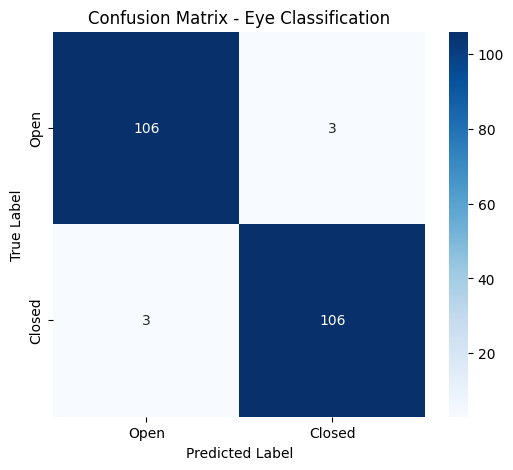

In [10]:
# Evaluate model
y_pred_eye_prob = eye_model.predict(X_test_eye)
y_pred_eye = (y_pred_eye_prob > 0.5).astype(int).flatten()

eye_accuracy = accuracy_score(y_test_eye, y_pred_eye)

print("="*50)
print("EYE CLASSIFICATION MODEL PERFORMANCE")
print("="*50)
print(f"Test Accuracy: {eye_accuracy * 100:.2f}%")
print("="*50)

print("\nClassification Report:")
print(classification_report(y_test_eye, y_pred_eye, target_names=['Open', 'Closed']))

# Confusion Matrix
cm_eye = confusion_matrix(y_test_eye, y_pred_eye)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_eye, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Open', 'Closed'],
            yticklabels=['Open', 'Closed'])
plt.title('Confusion Matrix - Eye Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()